In [2]:
import pandas as pd

df = pd.read_csv("traffic.csv", encoding='latin1')

df.head()
df.columns

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')

First 5 rows:


,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


Total Sessions: 116257
Unique Users: 12155
Bounce Rate (%): 0.0


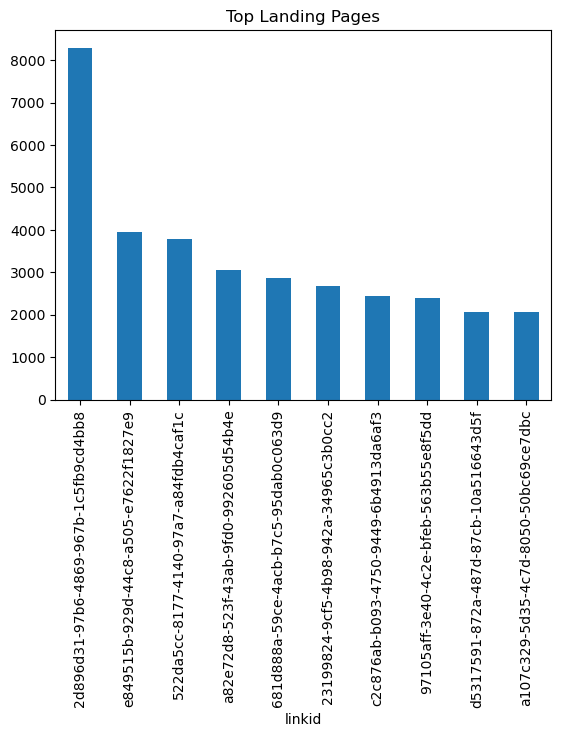

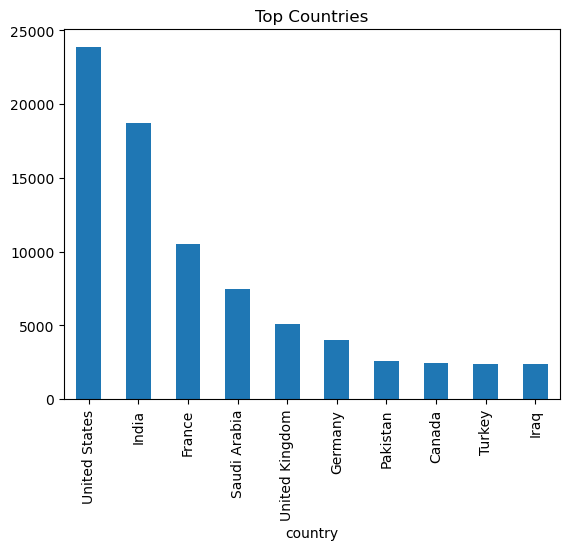

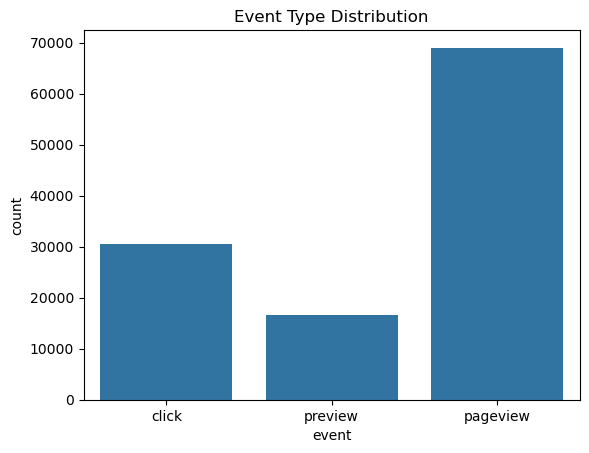

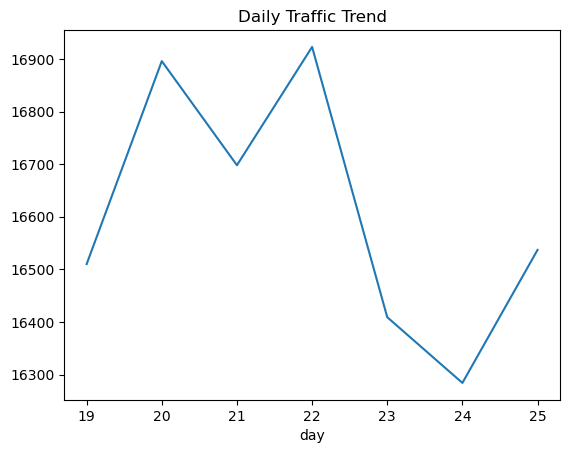

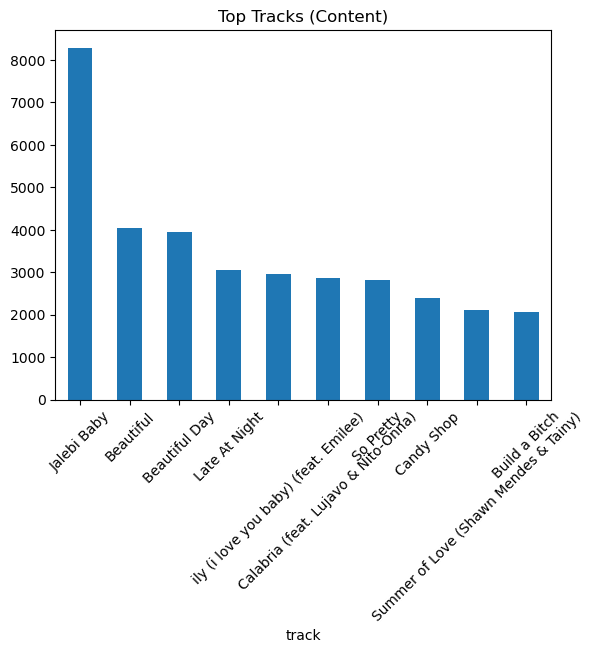


Final Data:


,event,date,country,city,artist,album,track,isrc,linkid,day
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,21
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores MÃ¡s,No Llores MÃ¡s,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,21
4,click,2021-08-21,Maldives,MalÃ©,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02,21


In [4]:
# ==============================
# STEP 1: IMPORT LIBRARIES
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# STEP 2: LOAD DATA
# ==============================

df = pd.read_csv("traffic.csv", encoding='latin1')

print("First 5 rows:")
display(df.head())

# ==============================
# STEP 3: DATA CLEANING
# ==============================

df = df.dropna()
df = df.drop_duplicates()

# Convert date
df["date"] = pd.to_datetime(df["date"], errors='coerce')

# ==============================
# STEP 4: BASIC METRICS
# ==============================

# Total events (sessions approx)
total_sessions = len(df)

# Unique users (approx using country + city)
unique_users = df[["country", "city"]].drop_duplicates().shape[0]

print("Total Sessions:", total_sessions)
print("Unique Users:", unique_users)

# ==============================
# STEP 5: BOUNCE RATE (APPROX)
# ==============================

# If event type available (like click/view)
bounce_events = df[df["event"] == "view"].shape[0]

bounce_rate = (bounce_events / total_sessions) * 100

print("Bounce Rate (%):", bounce_rate)

# ==============================
# STEP 6: TOP LANDING PAGES
# ==============================

top_pages = df["linkid"].value_counts().head(10)

plt.figure()
top_pages.plot(kind="bar")
plt.title("Top Landing Pages")
plt.show()

# ==============================
# STEP 7: TOP COUNTRIES
# ==============================

top_countries = df["country"].value_counts().head(10)

plt.figure()
top_countries.plot(kind="bar")
plt.title("Top Countries")
plt.show()

# ==============================
# STEP 8: EVENT TYPE ANALYSIS
# ==============================

plt.figure()
sns.countplot(x="event", data=df)
plt.title("Event Type Distribution")
plt.show()

# ==============================
# STEP 9: TIME ANALYSIS
# ==============================

df["day"] = df["date"].dt.day

daily_traffic = df.groupby("day").size()

plt.figure()
daily_traffic.plot()
plt.title("Daily Traffic Trend")
plt.show()

# ==============================
# STEP 10: TOP TRACKS (CONTENT)
# ==============================

top_tracks = df["track"].value_counts().head(10)

plt.figure()
top_tracks.plot(kind="bar")
plt.title("Top Tracks (Content)")
plt.xticks(rotation=45)
plt.show()

# ==============================
# STEP 11: FINAL OUTPUT
# ==============================

print("\nFinal Data:")
display(df.head())